<a href="https://colab.research.google.com/github/tristansalazar/MachineLearning-/blob/main/Unidad2/Practica4_U2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from IPython.display import Markdown, display

display(Markdown("""
# Machine Learning y Deep Learning

**Unidad 2**

**Práctica 4:** Random Forest

**Facilitador:** *Dr. José Gabriel Rodríguez Rivas*

**Alumno:** Diego Tristán Salazar Rueda

## Random Forest

**Cómo funciona**
- Combina muchos árboles de decisión entrenados sobre diferentes subconjuntos de datos y características. La predicción final es el promedio de las predicciones de todos los árboles.

**Ventajas**
- Reduce el sobreajuste respecto a un solo árbol.
- Maneja bien relaciones complejas y no lineales.
- Proporciona mejor generalización que un árbol individual.

**Limitaciones**
- Menos interpretable que un solo árbol.
- Puede ser más lento y consumir más memoria.

**Diferencias frente a Regresión Lineal y Árboles de Decisión**

| Técnica | Linealidad | Flexibilidad | Overfitting | Interpretabilidad |
|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | Baja | Alta |
| Árbol de Decisión | Baja | Media | Alta | Media |
| **Random Forest** | Baja | **Alta** | Baja | Baja |

*Random Forest es una excelente opción cuando se quiere mejorar la precisión sin preocuparse tanto por la interpretabilidad.*
"""))


# Machine Learning y Deep Learning

**Unidad 2**

**Práctica 4:** Random Forest

**Facilitador:** *Dr. José Gabriel Rodríguez Rivas*

**Alumno:** Diego Tristán Salazar Rueda

## Random Forest

**Cómo funciona**
- Combina muchos árboles de decisión entrenados sobre diferentes subconjuntos de datos y características. La predicción final es el promedio de las predicciones de todos los árboles.

**Ventajas**
- Reduce el sobreajuste respecto a un solo árbol.
- Maneja bien relaciones complejas y no lineales.
- Proporciona mejor generalización que un árbol individual.

**Limitaciones**
- Menos interpretable que un solo árbol.
- Puede ser más lento y consumir más memoria.

**Diferencias frente a Regresión Lineal y Árboles de Decisión**

| Técnica | Linealidad | Flexibilidad | Overfitting | Interpretabilidad |
|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | Baja | Alta |
| Árbol de Decisión | Baja | Media | Alta | Media |
| **Random Forest** | Baja | **Alta** | Baja | Baja |

*Random Forest es una excelente opción cuando se quiere mejorar la precisión sin preocuparse tanto por la interpretabilidad.*


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("autos2.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [3]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Coeficiente de determinación (R²): {r2_rf:.2f}")

Error cuadrático medio (MSE): 9610978.35
Coeficiente de determinación (R²): 0.92


In [7]:
rmse = np.sqrt(mse_rf)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 3100.16


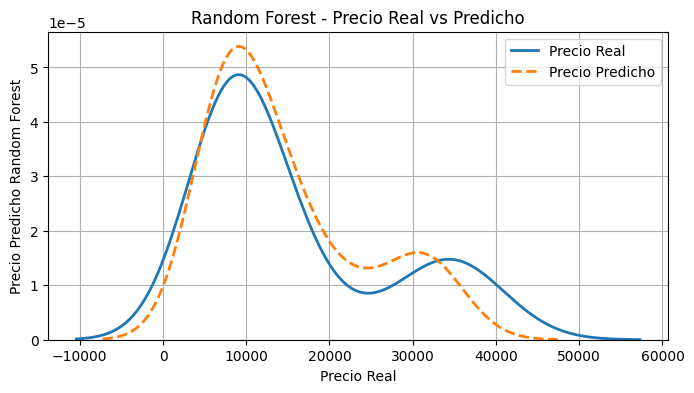

In [8]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_rf, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()

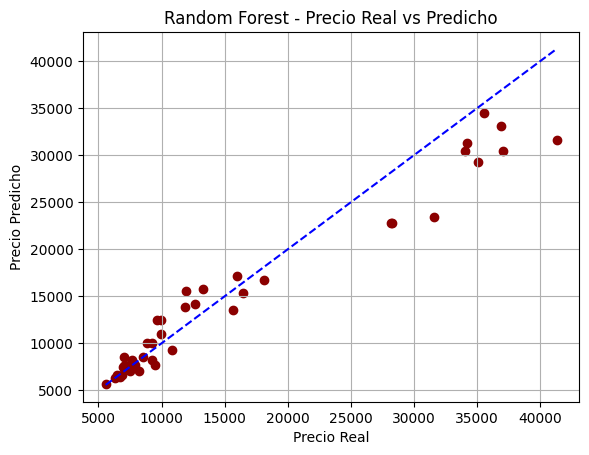

In [9]:
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")

MSE: 14091439.04
R²: 0.88
RMSE: 3753.86


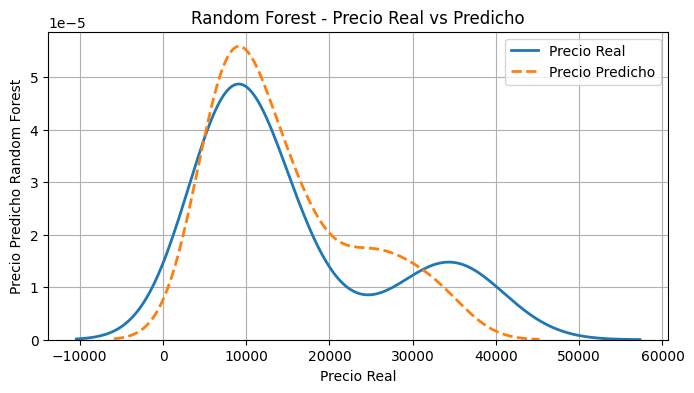

In [11]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()

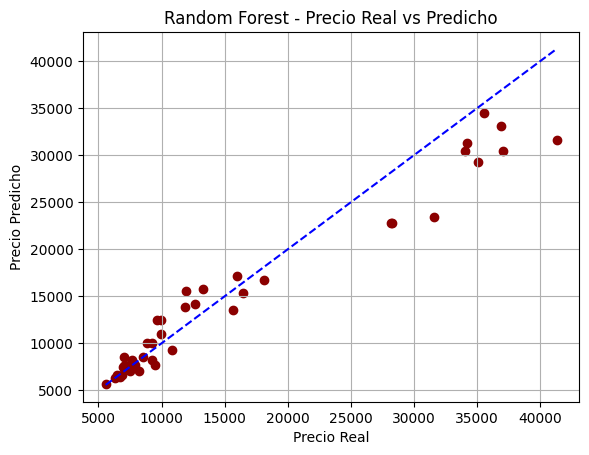

In [12]:
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R²:", grid_search.best_score_)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Mejores parámetros: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R²: 0.8587725936185243


MSE: 14200068.19
R²: 0.88
RMSE: 3768.30


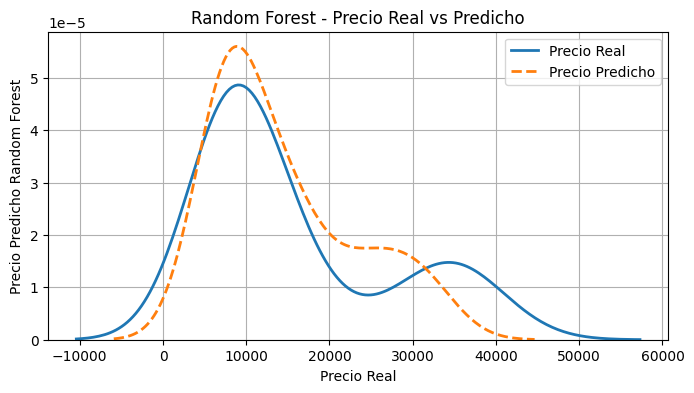

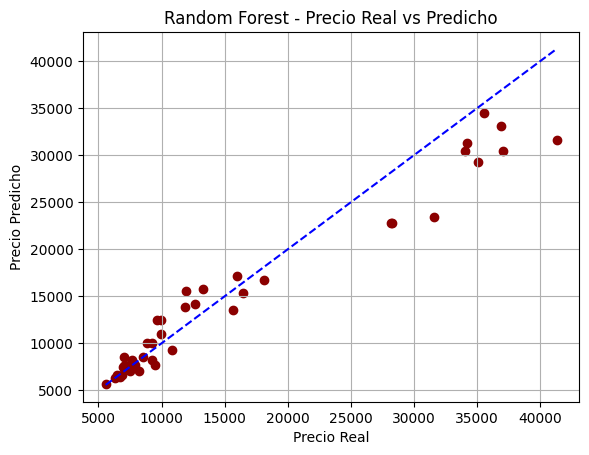

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")

plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()